<center><h1>Numerical linear algebra</h1></center>
<center><h3>The Jacobi and Gauss-Seidel methods</h3></center>

- - - - - - - - - - - - - - -

In [1]:
import numpy as np
from IPython.display import Image

- - - - - - - - - - - - - - -

Consider the linear system of equations

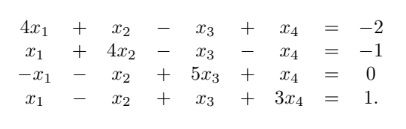

In [2]:
Image('equations.jpg')

Use the <b>Jacobi</b> method to solve the system of equations to within a tolerance of $||r^{(k)}||_{\infty} < 10^{-3}$, beginning from an initial guess $x^{(0)} = 0$, where $r^{(k)} = b - Ax^{(k)}$. Report the approximate solution $x^{(k)}$ and number of iterations $k$ required.

In [3]:
def Jacobi(A, b, T, x, tol = 1e-3):
    '''We initialise x as an array of zeros, and then afterwards we can replace that with our guesses.'''
    x = np.zeros(len(A[0]))
    
    '''This will let us isolate the diagonal of the matrix and turn it into its own matrix.'''
    C = np.diag(A)
    D = np.diagflat(C)

    '''I will be the identity matrix, where the diagonal length will be determined by the size of A.'''
    I = np.identity(len(A[0]))

    '''This will get the inverse of the diagonal matrix.'''
    D_inv = np.linalg.inv(D)

    '''The solution is then obtained iteratively as:'''
    '''x**(k+1) = D**(-1)b + (I - D**(-1)A)x**k'''
    '''where D**(-1)b, D**(-1)A, and (I - D**(-1)A)x**k are all calculated through the dot product.'''
    results = []

    '''This will keep count of the amount of iterations needed.'''
    iter = 0
    
    for _ in range(T):
        x_next = D_inv @ b + (I - (D_inv @ A)) @ x
        '''Without ord = np.inf, np.linalg.norm defaults to L2 norm.'''
        error = np.linalg.norm(x - x_next, ord = np.inf)
        if error < tol:
            iter += 1
            results.append(x_next)
            return results, iter
        x = x_next
        iter += 1
        
    return results, iter

if __name__ == "__main__":
    A = np.array([[4, 1, -1, 1], [1, 4, -1, -1], [-1, -1, 5, 1], [1, -1, 1, 3]])
    b = np.array([-2, -1, 0, 1])
    guess = np.array([0, 0, 0, 0])
    
    solution = Jacobi(A, b, T = 25, x = guess)
    
    print(f'Iterations needed: k = {solution[1]}')
    print(f'Approximate solution: x**(k) = {solution[0]}')

Iterations needed: k = 12
Approximate solution: x**(k) = [array([-0.75205599,  0.04027028, -0.28025957,  0.69008536])]


Repeat above with the <b>Gauss-Seidel</b> method and briefly compare results. Which method converges faster for this system?

In [4]:
def GaussSeidel(A, b, T, x, tol = 1e-3):
    '''We initialise x as an array of zeros, and then afterwards we can replace that with our guesses.'''
    x = np.zeros(len(A[0]))

    '''This will let us isolate the diagonal of the matrix and turn it into its own matrix.'''
    C = np.diag(A)
    D = np.diagflat(C)

    '''I will be the identity matrix, where the diagonal length will be determined by the size of A.'''
    I = np.identity(len(A[0]))
    
    '''This breaks the matrix of A into its upper and lower matrix components.'''
    lower = np.tril(A)
    upper = np.triu(A)
    
    '''This will get the inverse of the lower matrix.'''
    lower_inv = np.linalg.inv(lower)

    '''The solution is then obtained iteratively as:'''
    '''x**(k+1) = L**(-1)b + (I - L**(-1)A)x**k'''
    '''where L**(-1)b, L**(-1)A, and (I - L**(-1)A)x**k are all calculated through the dot product.'''
    results = []

    '''This will keep count of the amount of iterations needed.'''
    iter = 0
    
    for _ in range(T):
        x_next = lower_inv @ b + (I - (lower_inv @ A)) @ x
        '''Without ord = np.inf, np.linalg.norm defaults to L2 norm.'''
        error = np.linalg.norm(x - x_next, ord = np.inf)
        if error < tol:
            iter += 1
            results.append(x_next)
            return results, iter
        x = x_next
        iter += 1
        
    return results

if __name__ == "__main__":
    A = np.array([[4, 1, -1, 1], [1, 4, -1, -1], [-1, -1, 5, 1], [1, -1, 1, 3]])
    b = np.array([-2, -1, 0, 1])
    guess = np.array([0, 0, 0, 0])
    
    results, iter = GaussSeidel(A, b, T = 25, x = guess)
    
    print(f'Iterations needed: k = {iter}')
    print(f'Approximate solution: x**(k) = {results}')

Iterations needed: k = 8
Approximate solution: x**(k) = [array([-0.75317626,  0.04101049, -0.28070469,  0.69163048])]


The <b>Gauss-Seidel</b> method was faster by four iterations in this example.

## Further readings:
Reading material:<br>
https://www.amazon.com/Numerical-Analysis-Richard-L-Burden/dp/1305253663/

The @ symbol: <br>
https://stackoverflow.com/questions/6392739/what-does-the-at-symbol-do-in-python

## Useful links:
Quick definitions:<br>
https://mathworld.wolfram.com/JacobiMethod.html <br>
https://mathworld.wolfram.com/Gauss-SeidelMethod.html